#1) Jobs

#Remove and Classify Common records fron Green Jobs Sweden and Lignite Jobs Sweden

In [ ]:
import json

FILE_1 = "skillab_jobs_sweden_lignite_occupations.json"
FILE_2 = "skillab_jobs_sweden_green_occupations.json"
OUTPUT_FILE = "common_jobs_sweden.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 8613
Saved to common_jobs_sweden.json


In [ ]:
import json
import csv

COMMON_FILE = "common_jobs_sweden.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_jobs_sweden.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_jobs = json.load(f)

# Load a CSV reference file and return the set of occupation URIs it contains
def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        # Try to find the column holding the ESCO occupation URI
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# Classify each common job by counting occupation matches against each reference set
for job in common_jobs:
    job_occupations = set(job.get("occupations", []))
    green_matches = len(job_occupations & green_ref)
    lignite_matches = len(job_occupations & lignite_ref)
    job["green_matches"] = green_matches
    job["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        job["classified_as"] = "green"
    elif lignite_matches > green_matches:
        job["classified_as"] = "lignite"
    else:
        job["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_jobs if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_jobs if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_jobs if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_jobs, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 2110, Lignite: 1926, Ambiguous: 4577
Saved to classified_jobs_sweden.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_jobs_sweden.json"
GREEN_FILE = "skillab_jobs_sweden_green_occupations.json"
LIGNITE_FILE = "skillab_jobs_sweden_lignite_occupations.json"

GREEN_OUTPUT = "skillab_jobs_sweden_green_occupations_clean.json"
LIGNITE_OUTPUT = "skillab_jobs_sweden_lignite_occupations_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_jobs = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_jobs = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_jobs = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_jobs_clean = [j for j in green_jobs if j["id"] not in ids_remove_from_green]
lignite_jobs_clean = [j for j in lignite_jobs if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_jobs)} -> {len(green_jobs_clean)} (removed {len(green_jobs) - len(green_jobs_clean)})")
print(f"Lignite: {len(lignite_jobs)} -> {len(lignite_jobs_clean)} (removed {len(lignite_jobs) - len(lignite_jobs_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_jobs_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_jobs_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 40900 -> 34397 (removed 6503)
Lignite: 30691 -> 24004 (removed 6687)
Saved to skillab_jobs_sweden_green_occupations_clean.json and skillab_jobs_sweden_lignite_occupations_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "skillab_jobs_sweden_green_occupations_clean.json"
LIGNITE_CLEAN_FILE = "skillab_jobs_sweden_lignite_occupations_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 34397 records
Lignite clean: 24004 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Jobs Greece and Lignite Jobs Greece

In [ ]:
import json

FILE_1 = "skillab_jobs_greece_lignite_occupations.json"
FILE_2 = "skillab_jobs_greece_green_occupations.json"
OUTPUT_FILE = "common_jobs_greece.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 840
Saved to common_jobs_greece.json


In [ ]:
import json
import csv

COMMON_FILE = "common_jobs_greece.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_jobs_greece.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_jobs = json.load(f)

# Load a CSV reference file and return the set of occupation URIs it contains
def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        # Try to find the column holding the ESCO occupation URI
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# Classify each common job by counting occupation matches against each reference set
for job in common_jobs:
    job_occupations = set(job.get("occupations", []))
    green_matches = len(job_occupations & green_ref)
    lignite_matches = len(job_occupations & lignite_ref)
    job["green_matches"] = green_matches
    job["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        job["classified_as"] = "green"
    elif lignite_matches > green_matches:
        job["classified_as"] = "lignite"
    else:
        job["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_jobs if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_jobs if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_jobs if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_jobs, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 217, Lignite: 145, Ambiguous: 478
Saved to classified_jobs_greece.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_jobs_greece.json"
GREEN_FILE = "skillab_jobs_greece_green_occupations.json"
LIGNITE_FILE = "skillab_jobs_greece_lignite_occupations.json"

GREEN_OUTPUT = "skillab_jobs_greece_green_occupations_clean.json"
LIGNITE_OUTPUT = "skillab_jobs_greece_lignite_occupations_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_jobs = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_jobs = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_jobs = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_jobs_clean = [j for j in green_jobs if j["id"] not in ids_remove_from_green]
lignite_jobs_clean = [j for j in lignite_jobs if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_jobs)} -> {len(green_jobs_clean)} (removed {len(green_jobs) - len(green_jobs_clean)})")
print(f"Lignite: {len(lignite_jobs)} -> {len(lignite_jobs_clean)} (removed {len(lignite_jobs) - len(lignite_jobs_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_jobs_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_jobs_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 4247 -> 3624 (removed 623)
Lignite: 3582 -> 2887 (removed 695)
Saved to skillab_jobs_greece_green_occupations_clean.json and skillab_jobs_greece_lignite_occupations_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "skillab_jobs_greece_green_occupations_clean.json"
LIGNITE_CLEAN_FILE = "skillab_jobs_greece_lignite_occupations_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 3624 records
Lignite clean: 2887 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Jobs Spain and Lignite Jobs Spain

In [ ]:
import json

FILE_1 = "skillab_jobs_spain_lignite_occupations.json"
FILE_2 = "skillab_jobs_spain_green_final.json"
OUTPUT_FILE = "common_jobs_spain.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 92
Saved to common_jobs_spain.json


In [ ]:
import json
import csv

COMMON_FILE = "common_jobs_spain.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_jobs_spain.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_jobs = json.load(f)

# Load a CSV reference file and return the set of occupation URIs it contains
def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        # Try to find the column holding the ESCO occupation URI
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# Classify each common job by counting occupation matches against each reference set
for job in common_jobs:
    job_occupations = set(job.get("occupations", []))
    green_matches = len(job_occupations & green_ref)
    lignite_matches = len(job_occupations & lignite_ref)
    job["green_matches"] = green_matches
    job["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        job["classified_as"] = "green"
    elif lignite_matches > green_matches:
        job["classified_as"] = "lignite"
    else:
        job["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_jobs if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_jobs if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_jobs if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_jobs, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 8, Ambiguous: 84
Saved to classified_jobs_spain.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_jobs_spain.json"
GREEN_FILE = "skillab_jobs_spain_green_final.json"
LIGNITE_FILE = "skillab_jobs_spain_lignite_occupations.json"

GREEN_OUTPUT = "skillab_jobs_spain_green_occupations_clean.json"
LIGNITE_OUTPUT = "skillab_jobs_spain_lignite_occupations_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_jobs = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_jobs = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_jobs = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_jobs_clean = [j for j in green_jobs if j["id"] not in ids_remove_from_green]
lignite_jobs_clean = [j for j in lignite_jobs if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_jobs)} -> {len(green_jobs_clean)} (removed {len(green_jobs) - len(green_jobs_clean)})")
print(f"Lignite: {len(lignite_jobs)} -> {len(lignite_jobs_clean)} (removed {len(lignite_jobs) - len(lignite_jobs_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_jobs_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_jobs_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 990 -> 898 (removed 92)
Lignite: 1049 -> 965 (removed 84)
Saved to skillab_jobs_spain_green_occupations_clean.json and skillab_jobs_spain_lignite_occupations_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "skillab_jobs_spain_green_occupations_clean.json"
LIGNITE_CLEAN_FILE = "skillab_jobs_spain_lignite_occupations_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 898 records
Lignite clean: 965 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Jobs Italy and Lignite Jobs Italy

In [ ]:
import json

FILE_1 = "skillab_jobs_italy_lignite_occupations.json"
FILE_2 = "skillab_jobs_italy_green_final.json"
OUTPUT_FILE = "common_jobs_italy.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 0
Saved to common_jobs_spain.json


#Remove and Classify Common records fron Green Jobs Romania and Lignite Jobs Romania

In [ ]:
import json

FILE_1 = "skillab_jobs_romania_lignite_occupations.json"
FILE_2 = "skillab_jobs_romania_green_skills.json"
OUTPUT_FILE = "common_jobs_romania.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 0
Saved to common_jobs_romania.json


#Remove and Classify Common records fron Green Jobs Poland and Lignite Jobs Poland

In [ ]:
import json

FILE_1 = "skillab_jobs_poland_lignite_occupations.json"
FILE_2 = "skillab_jobs_poland_green_final.json"
OUTPUT_FILE = "common_jobs_poland.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 13
Saved to common_jobs_poland.json


In [ ]:
import json
import csv

COMMON_FILE = "common_jobs_poland.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_jobs_poland.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_jobs = json.load(f)

# Load a CSV reference file and return the set of occupation URIs it contains
def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        # Try to find the column holding the ESCO occupation URI
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# Classify each common job by counting occupation matches against each reference set
for job in common_jobs:
    job_occupations = set(job.get("occupations", []))
    green_matches = len(job_occupations & green_ref)
    lignite_matches = len(job_occupations & lignite_ref)
    job["green_matches"] = green_matches
    job["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        job["classified_as"] = "green"
    elif lignite_matches > green_matches:
        job["classified_as"] = "lignite"
    else:
        job["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_jobs if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_jobs if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_jobs if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_jobs, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 9, Ambiguous: 4
Saved to classified_jobs_poland.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_jobs_poland.json"
GREEN_FILE = "skillab_jobs_poland_green_final.json"
LIGNITE_FILE = "skillab_jobs_poland_lignite_occupations.json"

GREEN_OUTPUT = "skillab_jobs_poland_green_occupations_clean.json"
LIGNITE_OUTPUT = "skillab_jobs_poland_lignite_occupations_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_jobs = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_jobs = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_jobs = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_jobs_clean = [j for j in green_jobs if j["id"] not in ids_remove_from_green]
lignite_jobs_clean = [j for j in lignite_jobs if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_jobs)} -> {len(green_jobs_clean)} (removed {len(green_jobs) - len(green_jobs_clean)})")
print(f"Lignite: {len(lignite_jobs)} -> {len(lignite_jobs_clean)} (removed {len(lignite_jobs) - len(lignite_jobs_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_jobs_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_jobs_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 558 -> 545 (removed 13)
Lignite: 395 -> 391 (removed 4)
Saved to skillab_jobs_poland_green_occupations_clean.json and skillab_jobs_poland_lignite_occupations_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "skillab_jobs_poland_green_occupations_clean.json"
LIGNITE_CLEAN_FILE = "skillab_jobs_poland_lignite_occupations_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 545 records
Lignite clean: 391 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Jobs Czechia and Lignite Jobs Czechia

In [ ]:
import json

FILE_1 = "skillab_jobs_czechia_lignite_occupations.json"
FILE_2 = "skillab_jobs_czechia_green_skills.json"
OUTPUT_FILE = "common_jobs_czechia.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 6
Saved to common_jobs_czechia.json


In [ ]:
import json
import csv

COMMON_FILE = "common_jobs_czechia.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_jobs_czechia.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_jobs = json.load(f)

# Load a CSV reference file and return the set of occupation URIs it contains
def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        # Try to find the column holding the ESCO occupation URI
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# Classify each common job by counting occupation matches against each reference set
for job in common_jobs:
    job_occupations = set(job.get("occupations", []))
    green_matches = len(job_occupations & green_ref)
    lignite_matches = len(job_occupations & lignite_ref)
    job["green_matches"] = green_matches
    job["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        job["classified_as"] = "green"
    elif lignite_matches > green_matches:
        job["classified_as"] = "lignite"
    else:
        job["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_jobs if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_jobs if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_jobs if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_jobs, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 6, Ambiguous: 0
Saved to classified_jobs_czechia.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_jobs_czechia.json"
GREEN_FILE = "skillab_jobs_czechia_green_skills.json"
LIGNITE_FILE = "skillab_jobs_czechia_lignite_occupations.json"

GREEN_OUTPUT = "jobs_czechia_green_clean.json"
LIGNITE_OUTPUT = "jobs_czechia_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_jobs = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_jobs = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_jobs = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_jobs_clean = [j for j in green_jobs if j["id"] not in ids_remove_from_green]
lignite_jobs_clean = [j for j in lignite_jobs if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_jobs)} -> {len(green_jobs_clean)} (removed {len(green_jobs) - len(green_jobs_clean)})")
print(f"Lignite: {len(lignite_jobs)} -> {len(lignite_jobs_clean)} (removed {len(lignite_jobs) - len(lignite_jobs_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_jobs_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_jobs_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 377 -> 371 (removed 6)
Lignite: 237 -> 237 (removed 0)
Saved to jobs_czechia_green_clean.json and jobs_czechia_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "jobs_czechia_green_clean.json"
LIGNITE_CLEAN_FILE = "jobs_czechia_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 371 records
Lignite clean: 237 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Jobs Germany and Lignite Jobs Germany

In [ ]:
import json

FILE_1 = "skillab_jobs_germany_lignite_occupations.json"
FILE_2 = "skillab_jobs_germany_green_occupations.json"
OUTPUT_FILE = "common_jobs_germany.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 3780
Saved to common_jobs_germany.json


In [ ]:
import json
import csv

COMMON_FILE = "common_jobs_germany.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_jobs_germany.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_jobs = json.load(f)

# Load a CSV reference file and return the set of occupation URIs it contains
def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        # Try to find the column holding the ESCO occupation URI
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# Classify each common job by counting occupation matches against each reference set
for job in common_jobs:
    job_occupations = set(job.get("occupations", []))
    green_matches = len(job_occupations & green_ref)
    lignite_matches = len(job_occupations & lignite_ref)
    job["green_matches"] = green_matches
    job["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        job["classified_as"] = "green"
    elif lignite_matches > green_matches:
        job["classified_as"] = "lignite"
    else:
        job["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_jobs if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_jobs if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_jobs if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_jobs, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 337, Lignite: 900, Ambiguous: 2543
Saved to classified_jobs_germany.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_jobs_germany.json"
GREEN_FILE = "skillab_jobs_germany_green_occupations.json"
LIGNITE_FILE = "skillab_jobs_germany_lignite_occupations.json"

GREEN_OUTPUT = "jobs_germany_green_clean.json"
LIGNITE_OUTPUT = "jobs_germany_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_jobs = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_jobs = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_jobs = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_jobs_clean = [j for j in green_jobs if j["id"] not in ids_remove_from_green]
lignite_jobs_clean = [j for j in lignite_jobs if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_jobs)} -> {len(green_jobs_clean)} (removed {len(green_jobs) - len(green_jobs_clean)})")
print(f"Lignite: {len(lignite_jobs)} -> {len(lignite_jobs_clean)} (removed {len(lignite_jobs) - len(lignite_jobs_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_jobs_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_jobs_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 27232 -> 23789 (removed 3443)
Lignite: 50889 -> 48009 (removed 2880)
Saved to jobs_germany_green_clean.json and jobs_germany_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "jobs_germany_green_clean.json"
LIGNITE_CLEAN_FILE = "jobs_germany_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 23789 records
Lignite clean: 48009 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Jobs France and Lignite Jobs France

In [ ]:
import json

FILE_1 = "skillab_jobs_france_lignite_occupations.json"
FILE_2 = "skillab_jobs_france_green_occupations.json"
OUTPUT_FILE = "common_jobs_france.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 4885
Saved to common_jobs_france.json


In [ ]:
import json
import csv

COMMON_FILE = "common_jobs_france.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_jobs_france.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_jobs = json.load(f)

# Load a CSV reference file and return the set of occupation URIs it contains
def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        # Try to find the column holding the ESCO occupation URI
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# Classify each common job by counting occupation matches against each reference set
for job in common_jobs:
    job_occupations = set(job.get("occupations", []))
    green_matches = len(job_occupations & green_ref)
    lignite_matches = len(job_occupations & lignite_ref)
    job["green_matches"] = green_matches
    job["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        job["classified_as"] = "green"
    elif lignite_matches > green_matches:
        job["classified_as"] = "lignite"
    else:
        job["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_jobs if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_jobs if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_jobs if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_jobs, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 515, Lignite: 365, Ambiguous: 4005
Saved to classified_jobs_france.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_jobs_france.json"
GREEN_FILE = "skillab_jobs_france_green_occupations.json"
LIGNITE_FILE = "skillab_jobs_france_lignite_occupations.json"

GREEN_OUTPUT = "jobs_france_green_clean.json"
LIGNITE_OUTPUT = "jobs_france_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_jobs = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_jobs = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_jobs = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_jobs if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_jobs_clean = [j for j in green_jobs if j["id"] not in ids_remove_from_green]
lignite_jobs_clean = [j for j in lignite_jobs if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_jobs)} -> {len(green_jobs_clean)} (removed {len(green_jobs) - len(green_jobs_clean)})")
print(f"Lignite: {len(lignite_jobs)} -> {len(lignite_jobs_clean)} (removed {len(lignite_jobs) - len(lignite_jobs_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_jobs_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_jobs_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 45072 -> 40702 (removed 4370)
Lignite: 42674 -> 38154 (removed 4520)
Saved to jobs_france_green_clean.json and jobs_france_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "jobs_france_green_clean.json"
LIGNITE_CLEAN_FILE = "jobs_france_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 40702 records
Lignite clean: 38154 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Plots

#Green Jobs per country

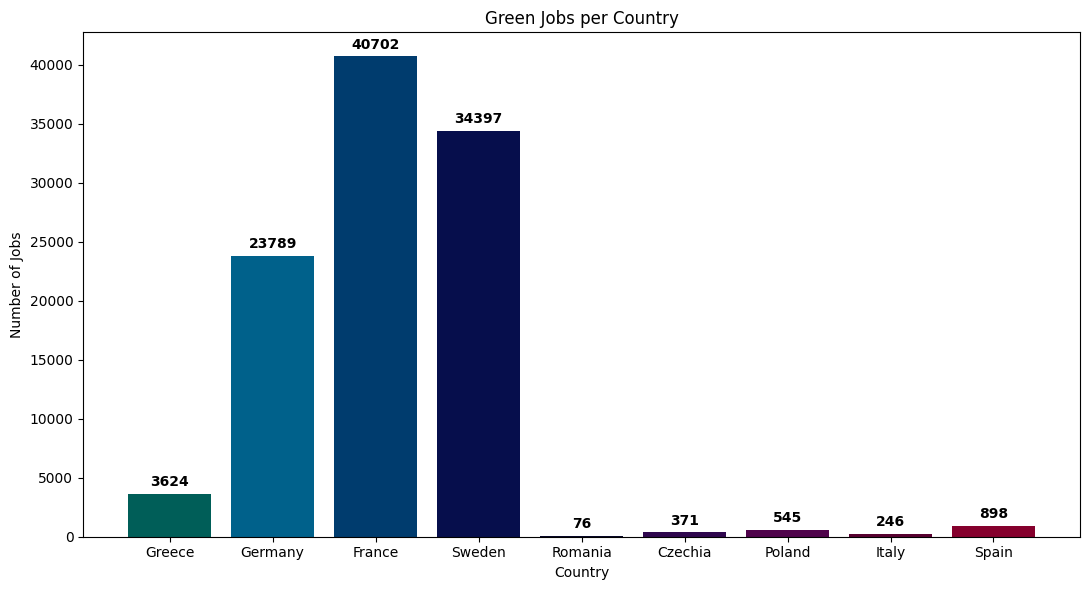

In [ ]:
import json
import matplotlib.pyplot as plt

# Dictionary with file paths for each country
occupation_files = {
    "Greece":  "jobs_greece_green_clean.json",
    "Germany": "jobs_germany_green_clean.json",
    "France":  "jobs_france_green_clean.json",
    "Sweden":  "jobs_sweden_green_clean.json",
    "Romania": "jobs_romania_green_clean.json",
    "Czechia": "jobs_czechia_green_clean.json",
    "Poland":  "jobs_poland_green_clean.json",
    "Italy":   "jobs_italy_green_clean.json",
    "Spain":   "jobs_spain_green_clean.json",
}

countries_to_plot = ["Greece", "Germany", "France", "Sweden", "Romania", "Czechia", "Poland", "Italy", "Spain"]

# Custom gradient colors (teal-green -> navy -> purple -> burgundy), one per country in order
custom_colors = [
    "#005E58",  # Greece
    "#00618B",  # Germany
    "#003C6E",  # France
    "#060E4C",  # Sweden
    "#080828",  # Romania
    "#2F074E",  # Czechia
    "#4F034B",  # Poland
    "#57002F",  # Italy
    "#85002D",  # Spain
]

counts = {}
for country in countries_to_plot:
    file_path = occupation_files[country]
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    counts[country] = len(data)

# Prepare data for plotting
countries = list(counts.keys())
values = list(counts.values())

# Plot
plt.figure(figsize=(11, 6))
bars = plt.bar(countries, values, color=custom_colors[:len(countries)])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{value}",
        ha="center", va="bottom", fontweight="bold"
    )

plt.title("Green Jobs per Country")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

#Lignite Jobs per country

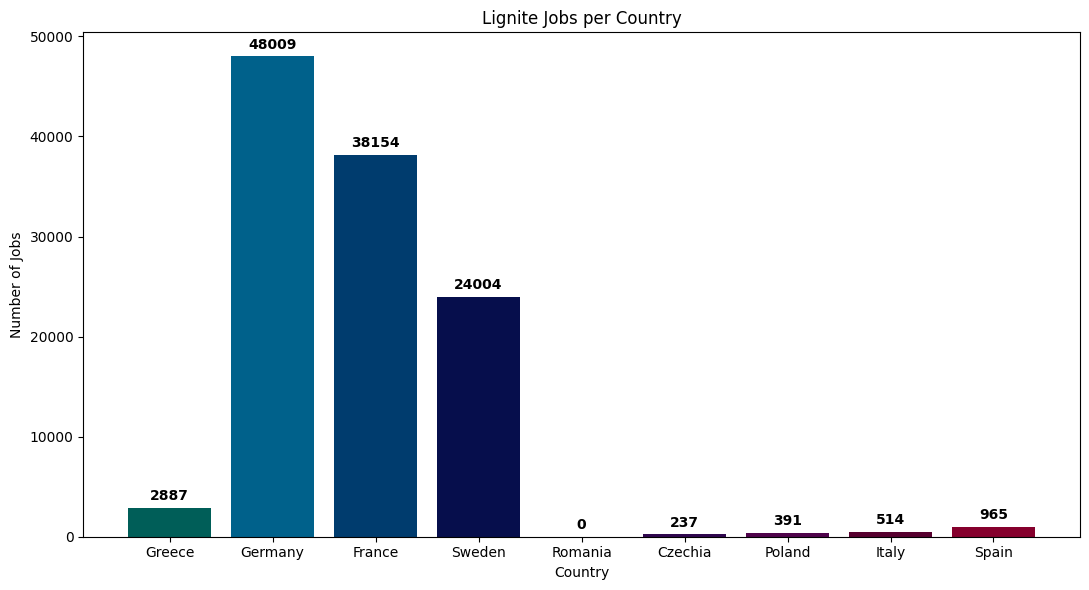

In [ ]:
import json
import matplotlib.pyplot as plt

# Dictionary with file paths for each country
occupation_files = {
    "Greece":  "jobs_greece_lignite_clean.json",
    "Germany": "jobs_germany_lignite_clean.json",
    "France":  "jobs_france_lignite_clean.json",
    "Sweden":  "jobs_sweden_lignite_clean.json",
    "Romania": "jobs_romania_lignite_clean.json",
    "Czechia": "jobs_czechia_lignite_clean.json",
    "Poland":  "jobs_poland_lignite_clean.json",
    "Italy":   "jobs_italy_lignite_clean.json",
    "Spain":   "jobs_spain_lignite_clean.json",
}

countries_to_plot = ["Greece", "Germany", "France", "Sweden", "Romania", "Czechia", "Poland", "Italy", "Spain"]

# Custom gradient colors (teal-green -> navy -> purple -> burgundy), one per country in order
custom_colors = [
    "#005E58",  # Greece
    "#00618B",  # Germany
    "#003C6E",  # France
    "#060E4C",  # Sweden
    "#080828",  # Romania
    "#2F074E",  # Czechia
    "#4F034B",  # Poland
    "#57002F",  # Italy
    "#85002D",  # Spain
]

counts = {}
for country in countries_to_plot:
    file_path = occupation_files[country]
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    counts[country] = len(data)

# Prepare data for plotting
countries = list(counts.keys())
values = list(counts.values())

# Plot
plt.figure(figsize=(11, 6))
bars = plt.bar(countries, values, color=custom_colors[:len(countries)])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{value}",
        ha="center", va="bottom", fontweight="bold"
    )

plt.title("Lignite Jobs per Country")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

#2) Profiles

#Remove and Classify Common records fron Green Profiles Sweden and Lignite Profiles Sweden

In [ ]:
import json

FILE_1 = "skillab_profiles_sweden_lignite_occupations.json"
FILE_2 = "skillab_profiles_sweden_green_occupations.json"
OUTPUT_FILE = "common_profiles_sweden.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 5
Saved to common_profiles_sweden.json


In [ ]:
import json
import csv

COMMON_FILE = "common_profiles_sweden.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_sweden.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 5
Saved to classified_profiles_sweden.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_profiles_sweden.json"
GREEN_FILE = "skillab_profiles_sweden_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_sweden_lignite_occupations.json"

GREEN_OUTPUT = "profiles_sweden_green_clean.json"
LIGNITE_OUTPUT = "profiles_sweden_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 10141 -> 10136 (removed 5)
Lignite: 9105 -> 9100 (removed 5)
Saved to profiles_sweden_green_clean.json and profiles_sweden_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "profiles_sweden_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_sweden_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 10136 records
Lignite clean: 9100 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Profiles Greece and Lignite Profiles Greece

In [ ]:
import json

FILE_1 = "skillab_profiles_greece_lignite_occupations.json"
FILE_2 = "skillab_profiles_greece_green_occupations.json"
OUTPUT_FILE = "common_profiles_greece.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 0
Saved to common_profiles_greece.json


In [ ]:
import json
import csv

COMMON_FILE = "common_profiles_greece.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_greece.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 0
Saved to classified_profiles_greece.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_profiles_greece.json"
GREEN_FILE = "skillab_profiles_greece_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_greece_lignite_occupations.json"

GREEN_OUTPUT = "profiles_greece_green_clean.json"
LIGNITE_OUTPUT = "profiles_greece_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 4913 -> 4913 (removed 0)
Lignite: 3247 -> 3247 (removed 0)
Saved to profiles_greece_green_clean.json and profiles_greece_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "profiles_greece_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_greece_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 4913 records
Lignite clean: 3247 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Profiles Italy and Lignite Profiles Italy

In [ ]:
import json

FILE_1 = "skillab_profiles_italy_lignite_occupations.json"
FILE_2 = "skillab_profiles_italy_green_occupations.json"
OUTPUT_FILE = "common_profiles_italy.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 11
Saved to common_profiles_italy.json


In [ ]:
import json
import csv

COMMON_FILE = "common_profiles_italy.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_italy.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 11
Saved to classified_profiles_italy.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_profiles_italy.json"
GREEN_FILE = "skillab_profiles_italy_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_italy_lignite_occupations.json"

GREEN_OUTPUT = "profiles_italy_green_clean.json"
LIGNITE_OUTPUT = "profiles_italy_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 37331 -> 37320 (removed 11)
Lignite: 23301 -> 23290 (removed 11)
Saved to profiles_italy_green_clean.json and profiles_italy_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "profiles_italy_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_italy_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 37320 records
Lignite clean: 23290 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Profiles Spain and Lignite Profiles Spain

In [ ]:
import json

FILE_1 = "skillab_profiles_spain_lignite_occupations.json"
FILE_2 = "skillab_profiles_spain_green_occupations.json"
OUTPUT_FILE = "common_profiles_spain.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 8
Saved to common_profiles_spain.json


In [ ]:
import json
import csv

COMMON_FILE = "common_profiles_spain.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_spain.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 8
Saved to classified_profiles_spain.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_profiles_spain.json"
GREEN_FILE = "skillab_profiles_spain_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_spain_lignite_occupations.json"

GREEN_OUTPUT = "profiles_spain_green_clean.json"
LIGNITE_OUTPUT = "profiles_spain_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 27715 -> 27707 (removed 8)
Lignite: 21851 -> 21843 (removed 8)
Saved to profiles_spain_green_clean.json and profiles_spain_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "profiles_spain_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_spain_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 27707 records
Lignite clean: 21843 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Profiles Romania and Lignite Profiles Romania

In [ ]:
import json

FILE_1 = "skillab_profiles_romania_lignite_occupations.json"
FILE_2 = "skillab_profiles_romania_green_occupations.json"
OUTPUT_FILE = "common_profiles_romania.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 4
Saved to common_profiles_romania.json


In [ ]:
import json
import csv

COMMON_FILE = "common_profiles_romania.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_romania.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 4
Saved to classified_profiles_romania.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_profiles_romania.json"
GREEN_FILE = "skillab_profiles_romania_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_romania_lignite_occupations.json"

GREEN_OUTPUT = "profiles_romania_green_clean.json"
LIGNITE_OUTPUT = "profiles_romania_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 8001 -> 7997 (removed 4)
Lignite: 5161 -> 5157 (removed 4)
Saved to profiles_romania_green_clean.json and profiles_romania_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "profiles_romania_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_romania_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 7997 records
Lignite clean: 5157 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Profiles Poland and Lignite Profiles Poland

In [ ]:
import json

FILE_1 = "skillab_profiles_poland_lignite_occupations.json"
FILE_2 = "skillab_profiles_poland_green_occupations.json"
OUTPUT_FILE = "common_profiles_poland.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 4
Saved to common_profiles_poland.json


In [ ]:
import json
import csv

COMMON_FILE = "common_profiles_poland.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_poland.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 4
Saved to classified_profiles_poland.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_profiles_poland.json"
GREEN_FILE = "skillab_profiles_poland_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_poland_lignite_occupations.json"

GREEN_OUTPUT = "profiles_poland_green_clean.json"
LIGNITE_OUTPUT = "profiles_poland_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 8748 -> 8744 (removed 4)
Lignite: 8735 -> 8731 (removed 4)
Saved to profiles_poland_green_clean.json and profiles_poland_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "profiles_poland_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_poland_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 8744 records
Lignite clean: 8731 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Profiles Czechia and Lignite Profiles Czechia

In [ ]:
import json

FILE_1 = "skillab_profiles_czechia_lignite_occupations.json"
FILE_2 = "skillab_profiles_czechia_green_occupations.json"
OUTPUT_FILE = "common_profiles_czechia.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 2
Saved to common_profiles_czechia.json


In [ ]:
import json
import csv

COMMON_FILE = "common_profiles_czechia.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_czechia.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 2
Saved to classified_profiles_czechia.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_profiles_czechia.json"
GREEN_FILE = "skillab_profiles_czechia_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_czechia_lignite_occupations.json"

GREEN_OUTPUT = "profiles_czechia_green_clean.json"
LIGNITE_OUTPUT = "profiles_czechia_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 3066 -> 3064 (removed 2)
Lignite: 3038 -> 3036 (removed 2)
Saved to profiles_czechia_green_clean.json and profiles_czechia_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "profiles_czechia_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_czechia_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 3064 records
Lignite clean: 3036 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Profiles Germany and Lignite Profiles Germany

In [ ]:
import json

FILE_1 = "skillab_profiles_germany_lignite_occupations.json"
FILE_2 = "skillab_profiles_germany_green_occupations.json"
OUTPUT_FILE = "common_profiles_germany.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 22
Saved to common_profiles_germany.json


In [ ]:
import json
import csv

COMMON_FILE = "common_profiles_germany.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_germany.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 22
Saved to classified_profiles_germany.json


In [ ]:
import json

CLASSIFIED_FILE = "classified_profiles_germany.json"
GREEN_FILE = "skillab_profiles_germany_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_germany_lignite_occupations.json"

GREEN_OUTPUT = "profiles_germany_green_clean.json"
LIGNITE_OUTPUT = "profiles_germany_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 34579 -> 34557 (removed 22)
Lignite: 25729 -> 25707 (removed 22)
Saved to profiles_germany_green_clean.json and profiles_germany_lignite_clean.json


In [ ]:
import json

GREEN_CLEAN_FILE = "profiles_germany_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_germany_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 34557 records
Lignite clean: 25707 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Remove and Classify Common records fron Green Profiles France and Lignite Profiles France

In [80]:
import json

FILE_1 = "skillab_profiles_france_lignite_occupations.json"
FILE_2 = "skillab_profiles_france_green_occupations.json"
OUTPUT_FILE = "common_profiles_france.json"

# Load both JSON files
with open(FILE_1, "r", encoding="utf-8") as f:
    data_1 = json.load(f)

with open(FILE_2, "r", encoding="utf-8") as f:
    data_2 = json.load(f)

# Build id -> record maps
ids_1 = {r["id"]: r for r in data_1}
ids_2 = {r["id"]: r for r in data_2}

# Find common ids and keep the matching records
common_ids = set(ids_1.keys()) & set(ids_2.keys())
common_records = [ids_1[_id] for _id in sorted(common_ids)]

print(f"Common records found: {len(common_records)}")

# Save to output file
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_records, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Common records found: 44
Saved to common_profiles_france.json


In [81]:
import json
import csv

COMMON_FILE = "common_profiles_france.json"
GREEN_REF_FILE = "highly_green_occupations.csv"
LIGNITE_REF_FILE = "lignite_occupations.csv"
OUTPUT_FILE = "classified_profiles_france.json"

with open(COMMON_FILE, "r", encoding="utf-8") as f:
    common_profiles = json.load(f)

def to_uri_set_from_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames
        uri_col = next((c for c in columns if "uri" in c.lower() or "esco" in c.lower()), columns[0])
        return {row[uri_col].strip() for row in reader if row[uri_col]}

green_ref = to_uri_set_from_csv(GREEN_REF_FILE)
lignite_ref = to_uri_set_from_csv(LIGNITE_REF_FILE)

# FIX: profiles use "occupation_uris", not "occupations"
for profile in common_profiles:
    profile_occupations = set(profile.get("occupation_uris", []))
    green_matches = len(profile_occupations & green_ref)
    lignite_matches = len(profile_occupations & lignite_ref)
    profile["green_matches"] = green_matches
    profile["lignite_matches"] = lignite_matches
    if green_matches > lignite_matches:
        profile["classified_as"] = "green"
    elif lignite_matches > green_matches:
        profile["classified_as"] = "lignite"
    else:
        profile["classified_as"] = "ambiguous"

green_count = sum(1 for j in common_profiles if j["classified_as"] == "green")
lignite_count = sum(1 for j in common_profiles if j["classified_as"] == "lignite")
ambiguous_count = sum(1 for j in common_profiles if j["classified_as"] == "ambiguous")
print(f"Green: {green_count}, Lignite: {lignite_count}, Ambiguous: {ambiguous_count}")

# FIX: was json.dump(common_jobs, ...) - wrong/stale variable name
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(common_profiles, f, ensure_ascii=False, indent=4)

print(f"Saved to {OUTPUT_FILE}")

Green: 0, Lignite: 0, Ambiguous: 44
Saved to classified_profiles_france.json


In [82]:
import json

CLASSIFIED_FILE = "classified_profiles_france.json"
GREEN_FILE = "skillab_profiles_france_green_occupations.json"
LIGNITE_FILE = "skillab_profiles_france_lignite_occupations.json"

GREEN_OUTPUT = "profiles_france_green_clean.json"
LIGNITE_OUTPUT = "profiles_france_lignite_clean.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_profiles = json.load(f)

with open(GREEN_FILE, "r", encoding="utf-8") as f:
    green_profiles = json.load(f)

with open(LIGNITE_FILE, "r", encoding="utf-8") as f:
    lignite_profiles = json.load(f)

# ids that ended up classified as lignite or ambiguous -> remove from green file
ids_remove_from_green = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("lignite", "ambiguous")
}

# ids that ended up classified as green or ambiguous -> remove from lignite file
ids_remove_from_lignite = {
    j["id"] for j in classified_profiles if j["classified_as"] in ("green", "ambiguous")
}

# Filter original files
green_profiles_clean = [j for j in green_profiles if j["id"] not in ids_remove_from_green]
lignite_profiles_clean = [j for j in lignite_profiles if j["id"] not in ids_remove_from_lignite]

print(f"Green: {len(green_profiles)} -> {len(green_profiles_clean)} (removed {len(green_profiles) - len(green_profiles_clean)})")
print(f"Lignite: {len(lignite_profiles)} -> {len(lignite_profiles_clean)} (removed {len(lignite_profiles) - len(lignite_profiles_clean)})")

with open(GREEN_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(green_profiles_clean, f, ensure_ascii=False, indent=4)

with open(LIGNITE_OUTPUT, "w", encoding="utf-8") as f:
    json.dump(lignite_profiles_clean, f, ensure_ascii=False, indent=4)

print(f"Saved to {GREEN_OUTPUT} and {LIGNITE_OUTPUT}")

Green: 54413 -> 54369 (removed 44)
Lignite: 45277 -> 45233 (removed 44)
Saved to profiles_france_green_clean.json and profiles_france_lignite_clean.json


In [83]:
import json

GREEN_CLEAN_FILE = "profiles_france_green_clean.json"
LIGNITE_CLEAN_FILE = "profiles_france_lignite_clean.json"

with open(GREEN_CLEAN_FILE, "r", encoding="utf-8") as f:
    green_clean = json.load(f)

with open(LIGNITE_CLEAN_FILE, "r", encoding="utf-8") as f:
    lignite_clean = json.load(f)

green_ids = {j["id"] for j in green_clean}
lignite_ids = {j["id"] for j in lignite_clean}

common_ids = green_ids & lignite_ids

print(f"Green clean: {len(green_ids)} records")
print(f"Lignite clean: {len(lignite_ids)} records")
print(f"Common records between clean files: {len(common_ids)}")

if common_ids:
    print("Common ids:", common_ids)
else:
    print("No common records found - cleaning was successful.")

Green clean: 54369 records
Lignite clean: 45233 records
Common records between clean files: 0
No common records found - cleaning was successful.


#Plots

#Green Profiles per country

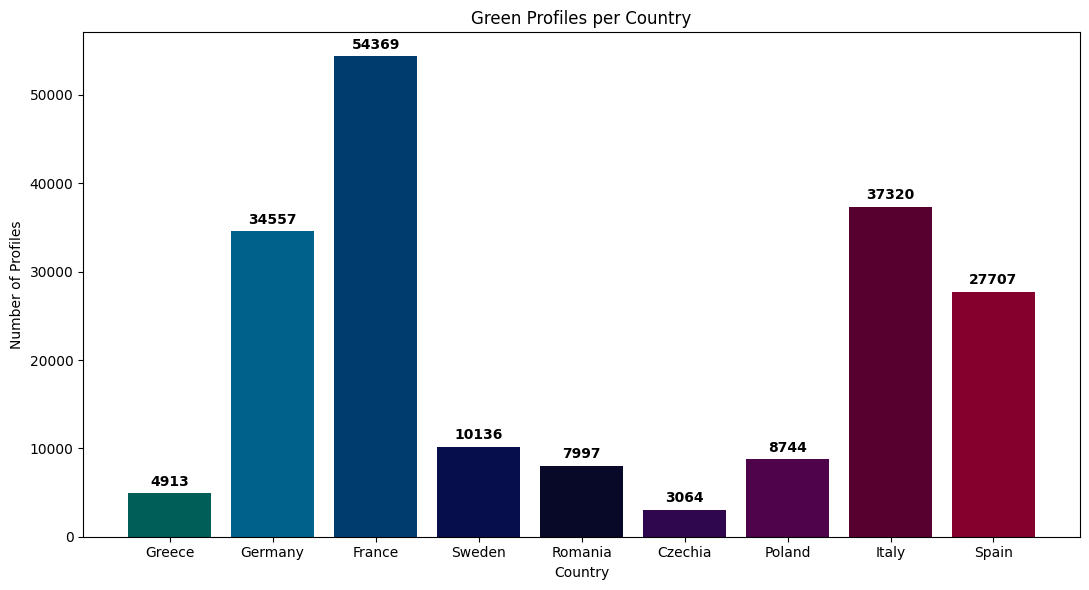

In [84]:
import json
import matplotlib.pyplot as plt

# Dictionary with file paths for each country
occupation_files = {
    "Greece":  "profiles_greece_green_clean.json",
    "Germany": "profiles_germany_green_clean.json",
    "France":  "profiles_france_green_clean.json",
    "Sweden":  "profiles_sweden_green_clean.json",
    "Romania": "profiles_romania_green_clean.json",
    "Czechia": "profiles_czechia_green_clean.json",
    "Poland":  "profiles_poland_green_clean.json",
    "Italy":   "profiles_italy_green_clean.json",
    "Spain":   "profiles_spain_green_clean.json",
}

countries_to_plot = ["Greece", "Germany", "France", "Sweden", "Romania", "Czechia", "Poland", "Italy", "Spain"]

# Custom gradient colors (teal-green -> navy -> purple -> burgundy), one per country in order
custom_colors = [
    "#005E58",  # Greece
    "#00618B",  # Germany
    "#003C6E",  # France
    "#060E4C",  # Sweden
    "#080828",  # Romania
    "#2F074E",  # Czechia
    "#4F034B",  # Poland
    "#57002F",  # Italy
    "#85002D",  # Spain
]

counts = {}
for country in countries_to_plot:
    file_path = occupation_files[country]
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    counts[country] = len(data)

# Prepare data for plotting
countries = list(counts.keys())
values = list(counts.values())

# Plot
plt.figure(figsize=(11, 6))
bars = plt.bar(countries, values, color=custom_colors[:len(countries)])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{value}",
        ha="center", va="bottom", fontweight="bold"
    )

plt.title("Green Profiles per Country")
plt.xlabel("Country")
plt.ylabel("Number of Profiles")
plt.tight_layout()
plt.show()

#Lignite Profiles per country

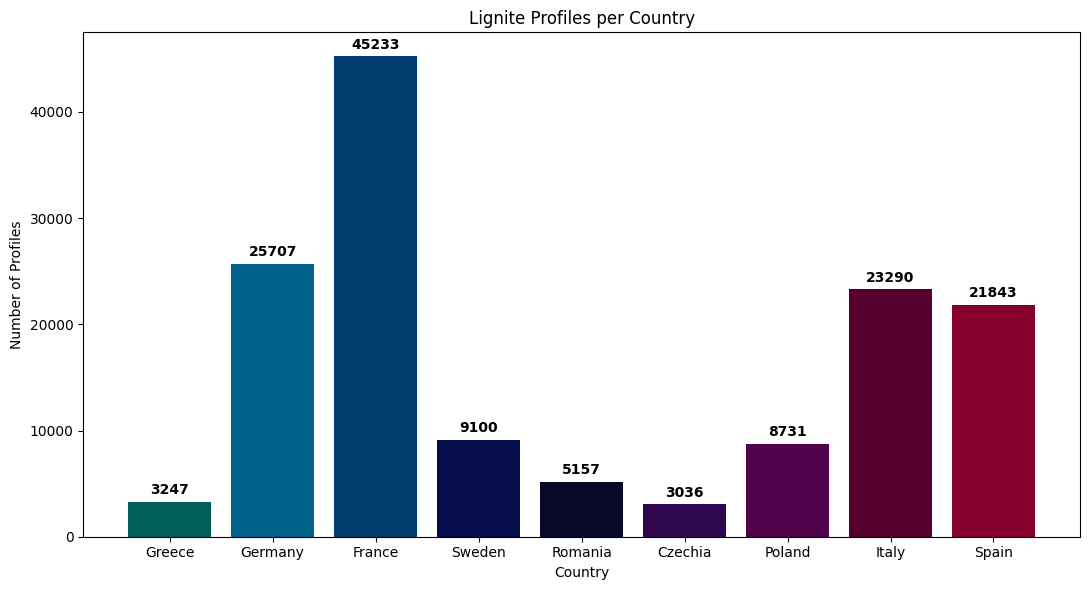

In [85]:
import json
import matplotlib.pyplot as plt

# Dictionary with file paths for each country
occupation_files = {
    "Greece":  "profiles_greece_lignite_clean.json",
    "Germany": "profiles_germany_lignite_clean.json",
    "France":  "profiles_france_lignite_clean.json",
    "Sweden":  "profiles_sweden_lignite_clean.json",
    "Romania": "profiles_romania_lignite_clean.json",
    "Czechia": "profiles_czechia_lignite_clean.json",
    "Poland":  "profiles_poland_lignite_clean.json",
    "Italy":   "profiles_italy_lignite_clean.json",
    "Spain":   "profiles_spain_lignite_clean.json",
}

countries_to_plot = ["Greece", "Germany", "France", "Sweden", "Romania", "Czechia", "Poland", "Italy", "Spain"]

# Custom gradient colors (teal-green -> navy -> purple -> burgundy), one per country in order
custom_colors = [
    "#005E58",  # Greece
    "#00618B",  # Germany
    "#003C6E",  # France
    "#060E4C",  # Sweden
    "#080828",  # Romania
    "#2F074E",  # Czechia
    "#4F034B",  # Poland
    "#57002F",  # Italy
    "#85002D",  # Spain
]

counts = {}
for country in countries_to_plot:
    file_path = occupation_files[country]
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    counts[country] = len(data)

# Prepare data for plotting
countries = list(counts.keys())
values = list(counts.values())

# Plot
plt.figure(figsize=(11, 6))
bars = plt.bar(countries, values, color=custom_colors[:len(countries)])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{value}",
        ha="center", va="bottom", fontweight="bold"
    )

plt.title("Lignite Profiles per Country")
plt.xlabel("Country")
plt.ylabel("Number of Profiles")
plt.tight_layout()
plt.show()